# Real-Time Speech Enhancement using PyTorch

**Goal:** take a *noisy* speech recording and produce a *cleaner* version of it.

We build the classic **spectral-masking** speech enhancer. The idea: speech and noise look
different in a spectrogram, so we train a small network to predict, for every time-frequency point,
*how much of it is speech* (a number between 0 and 1 called a **mask**). Multiplying the noisy
spectrogram by that mask keeps the speech and removes the noise.

```
clean speech (from Hugging Face)
       |
       |  add synthetic noise
       v
  noisy speech ---- STFT ----> noisy spectrogram
                                   |  magnitude
                                   v
                            [ simple CNN ]  -->  mask (0..1)
                                   |
   noisy phase --------------------+----> enhanced spectrogram = mask * magnitude * e^{j*phase}
                                                |
                                                v  ISTFT
                                          enhanced speech
```

**What this notebook does, end to end:**

1. **Download** clean speech from the Hugging Face Hub.
2. **Add noise** to it at a chosen SNR, creating `(noisy, clean)` training pairs.
3. **STFT** — turn the waveforms into magnitude + phase spectrograms.
4. **Simple CNN** — train a small PyTorch network to predict the speech mask.
5. **Reconstruct** the waveform (ISTFT) and listen to the result.
6. **Compare** our CNN against a *pretrained* model pulled from Hugging Face
   (SpeechBrain **MetricGAN+**).

**Tools:** PyTorch, Librosa, NumPy (plus `soundfile` for I/O and `matplotlib` for plots).

Run the cells top to bottom.

## Step 1 — Install dependencies

- `torch` / `torchaudio` — the CNN, STFT/ISTFT, training.
- `librosa` + `soundfile` — load and resample audio, draw spectrograms.
- `huggingface_hub` — download the speech data from the Hub.
- `speechbrain` — the pretrained MetricGAN+ model we compare against.

If a package is already installed, pip just skips it.

In [1]:
%pip install -q torch torchaudio librosa soundfile numpy matplotlib pandas huggingface_hub speechbrain


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Step 2 — Configuration

All the knobs in one place.

- `N_FFT` / `HOP` control the STFT resolution (512-point window, 128-sample hop -> 257 frequency
  bins at 16 kHz).
- `SEG_SECONDS` is the length of each training clip, so every spectrogram has the same size and we
  can batch them.
- `TRAIN_SNR_DB` is the *range* of noise levels used during training (random each time = data
  augmentation); `EVAL_SNR_DB` is the *fixed* level used for the final fair comparison.

In [2]:
from pathlib import Path
import numpy as np
import torch

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

SR           = 16000          # everything works at 16 kHz mono
N_FFT        = 512            # STFT window size  -> 257 frequency bins
HOP          = 128            # STFT hop length
SEG_SECONDS  = 1.5           # length of each training segment
SEG_SAMPLES  = int(SR * SEG_SECONDS)

TRAIN_SNR_DB = (-5.0, 10.0)   # random noise level during training (dB)
EVAL_SNR_DB  = 0.0            # fixed noise level for the final comparison (dB)
N_EVAL_CLIPS = 12             # how many held-out clips to evaluate on

EPOCHS       = 12
BATCH_SIZE   = 16
LR           = 1e-3
CHANNELS     = 24             # CNN width

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WINDOW = torch.hann_window(N_FFT)   # shared STFT/ISTFT window

print("device :", DEVICE)
print("STFT   :", N_FFT, "fft /", HOP, "hop ->", N_FFT // 2 + 1, "freq bins")

device : cpu
STFT   : 512 fft / 128 hop -> 257 freq bins


## Step 3 — Download clean speech from Hugging Face

We use a small, public clean-speech dataset from the Hub:
[`hf-internal-testing/librispeech_asr_dummy`](https://huggingface.co/datasets/hf-internal-testing/librispeech_asr_dummy)
— 73 LibriSpeech clips (~8 minutes total), already 16 kHz and clean.

The clips are stored inside a single Parquet file with the audio embedded as bytes, so we download
that one file and decode each clip with `soundfile` (no extra audio backend needed).

In [3]:
import io
import pandas as pd
import soundfile as sf
import librosa
from huggingface_hub import hf_hub_download

DATASET_REPO = "hf-internal-testing/librispeech_asr_dummy"
parquet_path = hf_hub_download(DATASET_REPO, "clean/validation-00000-of-00001.parquet", repo_type="dataset")
_df = pd.read_parquet(parquet_path)

def decode_clip(row):
    """Decode one Parquet row into a 1-D float32 waveform at SR Hz, mono."""
    wav, sr = sf.read(io.BytesIO(row["audio"]["bytes"]), dtype="float32")
    if wav.ndim > 1:
        wav = wav.mean(axis=1)                       # to mono
    if sr != SR:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SR)
    return wav.astype("float32")

clips = [decode_clip(_df.iloc[i]) for i in range(len(_df))]
print(f"{len(clips)} clean clips | {sum(len(c) for c in clips)/SR:.0f}s total")

from IPython.display import Audio, display
print("A clean speech sample:")
display(Audio(clips[0], rate=SR))

73 clean clips | 481s total
A clean speech sample:


## Step 4 — Add synthetic noise

To train an enhancer we need pairs of *(noisy, clean)* audio. We make the noisy version by adding
**Gaussian white noise** to a clean clip, scaled to hit a target **SNR** (signal-to-noise ratio):

- high SNR (e.g. +10 dB) = a little noise,
- low SNR (e.g. -5 dB) = a lot of noise.

`add_noise` below computes the exact scale needed for a requested SNR.

In [4]:
def add_noise(clean, snr_db, rng):
    """Add Gaussian white noise to `clean` at the given SNR (dB). Returns the noisy waveform."""
    noise = rng.standard_normal(len(clean)).astype("float32")
    sig_power = float(np.mean(clean ** 2)) + 1e-12
    noise_power = float(np.mean(noise ** 2)) + 1e-12
    scale = np.sqrt(sig_power / (noise_power * 10 ** (snr_db / 10)))
    return (clean + scale * noise).astype("float32")

_rng = np.random.default_rng(SEED)
_clean = clips[0]
_noisy = add_noise(_clean, EVAL_SNR_DB, _rng)
print(f"Clean vs noisy at {EVAL_SNR_DB:.0f} dB SNR:")
display(Audio(_clean, rate=SR))
display(Audio(_noisy, rate=SR))

Clean vs noisy at 0 dB SNR:


## Step 5 — STFT and ISTFT

The **STFT** (Short-Time Fourier Transform) turns a waveform into a complex spectrogram of shape
`(frequency, time)`. We split it into:

- **magnitude** — *how much* energy at each time/frequency (this is what the CNN sees and cleans),
- **phase** — the waveform's fine timing (we keep the noisy phase and reuse it when rebuilding).

The **ISTFT** is the inverse: complex spectrogram back to a waveform. The round-trip check below
should give a tiny reconstruction error.

In [5]:
def stft(wav):
    """Waveform tensor (T,) -> complex spectrogram (F, frames)."""
    return torch.stft(wav, N_FFT, HOP, N_FFT, WINDOW, return_complex=True)

def istft(spec, length=None):
    """Complex spectrogram (F, frames) -> waveform tensor (T,)."""
    return torch.istft(spec, N_FFT, HOP, N_FFT, WINDOW, length=length)

_x = torch.from_numpy(clips[0])
_roundtrip = istft(stft(_x), length=len(_x))
print("ISTFT(STFT(x)) reconstruction error:", torch.mean((_x - _roundtrip) ** 2).item())
print("spectrogram shape for a 1.5s segment:", tuple(stft(torch.from_numpy(clips[0][:SEG_SAMPLES])).shape))

ISTFT(STFT(x)) reconstruction error: 5.756720459670943e-17
spectrogram shape for a 1.5s segment: (257, 188)


## Step 6 — Build the training set

We hold out a few clips for evaluation, then cut the rest into fixed-length **1.5 s segments** so
every spectrogram has the same shape and can be batched.

The `NoisySpeech` dataset adds **fresh random noise** to each clean segment every time it is read,
so the network sees endless noisy variations of the same speech. For each item it returns:

- **input**: `log(1 + magnitude)` of the noisy segment (log keeps the numbers in a friendly range),
- **target**: the **Ideal Ratio Mask** `clean / (clean + noise)` — the perfect mask we want the
  CNN to imitate.

In [6]:
from torch.utils.data import Dataset, DataLoader

# split CLIPS (not segments) so evaluation clips are never seen in training
order = np.random.default_rng(SEED).permutation(len(clips))
eval_idx, train_idx = order[:N_EVAL_CLIPS], order[N_EVAL_CLIPS:]

def to_segments(clip):
    n = len(clip) // SEG_SAMPLES
    return [clip[i * SEG_SAMPLES:(i + 1) * SEG_SAMPLES] for i in range(n)]

train_segments = [seg for i in train_idx for seg in to_segments(clips[i])]
print(f"{len(train_idx)} train clips -> {len(train_segments)} segments | {len(eval_idx)} eval clips")

class NoisySpeech(Dataset):
    """Returns (log-magnitude of noisy, ideal ratio mask) for randomly-noised clean segments."""
    def __init__(self, segments, snr_range, seed=SEED):
        self.segments = segments
        self.snr_range = snr_range
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, i):
        clean = self.segments[i]
        snr = self.rng.uniform(*self.snr_range)
        noisy = add_noise(clean, snr, self.rng)

        clean_spec = stft(torch.from_numpy(clean))
        noisy_spec = stft(torch.from_numpy(noisy))
        clean_mag = clean_spec.abs()
        noisy_mag = noisy_spec.abs()
        noise_mag = (noisy_spec - clean_spec).abs()

        irm = (clean_mag / (clean_mag + noise_mag + 1e-8)).clamp(0, 1)   # target mask
        feat = torch.log1p(noisy_mag)                                    # CNN input
        return feat.unsqueeze(0), irm.unsqueeze(0)

train_loader = DataLoader(
    NoisySpeech(train_segments, TRAIN_SNR_DB),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
)
_feat, _mask = next(iter(train_loader))
print("batch input:", tuple(_feat.shape), "| batch target:", tuple(_mask.shape))

61 train clips -> 242 segments | 12 eval clips
batch input: (16, 1, 257, 188) | batch target: (16, 1, 257, 188)


## Step 7 — The simple CNN

A small **fully-convolutional** network. It slides 3x3 filters over the spectrogram, so it can look
at each time-frequency point together with its neighbours, and outputs one number per point. A final
**sigmoid** squashes the output into `[0, 1]` — exactly the range of a mask.

Because it is fully convolutional, it works on a spectrogram of *any* length, which is what lets us
train on 1.5 s segments but run it on full-length clips later.

In [7]:
import torch.nn as nn

class EnhancementCNN(nn.Module):
    """Log-magnitude spectrogram (B,1,F,T) -> soft mask (B,1,F,T) in [0,1]."""
    def __init__(self, ch=CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ch, 3, padding=1),  nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, 1, 3, padding=1),
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))

model = EnhancementCNN().to(DEVICE)
print(model)
print("trainable params:", f"{sum(p.numel() for p in model.parameters())/1e3:.1f} k")

EnhancementCNN(
  (net): Sequential(
    (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(24, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)
trainable params: 11.0 k


## Step 8 — Train the CNN

We train the network to make its predicted mask match the ideal ratio mask, using **mean-squared
error**. This is light enough to run on CPU in a couple of minutes.

epoch  1/12  mask MSE = 0.0694


epoch  2/12  mask MSE = 0.0386


epoch  3/12  mask MSE = 0.0334


epoch  4/12  mask MSE = 0.0338


epoch  5/12  mask MSE = 0.0346


...

epoch  8/12  mask MSE = 0.0312


epoch  9/12  mask MSE = 0.0321


epoch 10/12  mask MSE = 0.0305


epoch 11/12  mask MSE = 0.0310


epoch 12/12  mask MSE = 0.0307

trained in 231s on cpu


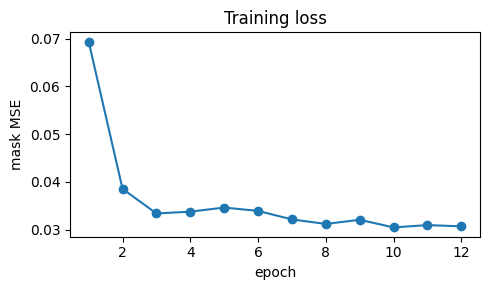

In [8]:
import time
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

history, t0 = [], time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for feat, irm in train_loader:
        feat, irm = feat.to(DEVICE), irm.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(feat), irm)
        loss.backward()
        optimizer.step()
        running += loss.item() * feat.size(0)
    epoch_loss = running / len(train_loader.dataset)
    history.append(epoch_loss)
    print(f"epoch {epoch:2d}/{EPOCHS}  mask MSE = {epoch_loss:.4f}")

print(f"\ntrained in {time.time() - t0:.0f}s on {DEVICE}")
plt.figure(figsize=(5, 3))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.xlabel("epoch"); plt.ylabel("mask MSE"); plt.title("Training loss")
plt.tight_layout(); plt.show()

## Step 9 — Reconstruct audio and evaluate

To enhance a full clip we: STFT it, predict the mask, multiply the **magnitude** by the mask, glue
the **original (noisy) phase** back on, and ISTFT to a waveform.

We measure quality with **SI-SNR** (scale-invariant signal-to-noise ratio, in dB — higher is
better). We report it on a held-out evaluation set, using the *same* fixed noisy clips for every
method so the comparison is fair.

In [9]:
def enhance_cnn(noisy_wav):
    """Enhance one clip with the trained CNN. Returns a waveform (numpy)."""
    model.eval()
    x = torch.from_numpy(np.asarray(noisy_wav, dtype="float32"))
    spec = stft(x)
    mag, phase = spec.abs(), torch.angle(spec)
    feat = torch.log1p(mag).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        mask = model(feat).squeeze(0).squeeze(0).cpu()
    enhanced_spec = torch.polar(mask * mag, phase)        # mask the magnitude, keep the phase
    return istft(enhanced_spec, length=len(x)).numpy()

def si_snr(reference, estimate, eps=1e-8):
    """Scale-invariant SNR in dB between a reference and an estimate waveform."""
    n = min(len(reference), len(estimate))
    ref = reference[:n].astype(np.float64); est = estimate[:n].astype(np.float64)
    ref = ref - ref.mean(); est = est - est.mean()
    alpha = np.dot(est, ref) / (np.dot(ref, ref) + eps)
    target = alpha * ref
    noise = est - target
    return 10 * np.log10((np.dot(target, target) + eps) / (np.dot(noise, noise) + eps))

# one fixed noisy clip per eval clip (reused by every model)
rng_eval = np.random.default_rng(123)
eval_set = [(clips[i], add_noise(clips[i], EVAL_SNR_DB, rng_eval)) for i in eval_idx]

snr_noisy = [si_snr(c, n) for c, n in eval_set]
snr_ours  = [si_snr(c, enhance_cnn(n)) for c, n in eval_set]
imp_ours  = float(np.mean(np.array(snr_ours) - np.array(snr_noisy)))
print(f"noisy input       : {np.mean(snr_noisy):+.2f} dB SI-SNR")
print(f"our CNN enhanced  : {np.mean(snr_ours):+.2f} dB SI-SNR   (improvement {imp_ours:+.2f} dB)")

noisy input       : +0.00 dB SI-SNR
our CNN enhanced  : +9.90 dB SI-SNR   (improvement +9.90 dB)


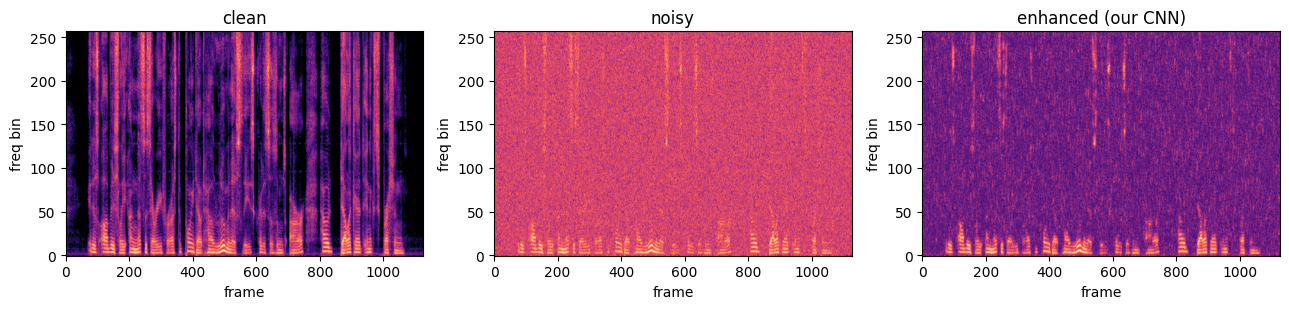

clean / noisy / enhanced (our CNN):


In [10]:
# look at and listen to one example
clean, noisy = eval_set[0]
enhanced = enhance_cnn(noisy)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (title, wav) in zip(axes, [("clean", clean), ("noisy", noisy), ("enhanced (our CNN)", enhanced)]):
    spec_db = librosa.amplitude_to_db(np.abs(librosa.stft(wav, n_fft=N_FFT, hop_length=HOP)), ref=np.max)
    ax.imshow(spec_db, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title); ax.set_xlabel("frame"); ax.set_ylabel("freq bin")
plt.tight_layout(); plt.show()

print("clean / noisy / enhanced (our CNN):")
display(Audio(clean, rate=SR)); display(Audio(noisy, rate=SR)); display(Audio(enhanced, rate=SR))

## Step 10 — Compare with a pretrained model from Hugging Face

Now we pull a *ready-made* speech enhancer from the Hub:
[`speechbrain/metricgan-plus-voicebank`](https://huggingface.co/speechbrain/metricgan-plus-voicebank).
**MetricGAN+** is also a spectral-mask model, but it was trained on **real-world recorded noise**
(VoiceBank-DEMAND) and optimized for **perceptual quality**, not SI-SNR.

We run it on the exact same noisy clips and measure SI-SNR the same way.

In [11]:
try:
    from speechbrain.inference.enhancement import SpectralMaskEnhancement
except Exception:
    from speechbrain.pretrained import SpectralMaskEnhancement

metricgan = SpectralMaskEnhancement.from_hparams(
    source="speechbrain/metricgan-plus-voicebank",
    savedir="pretrained_models/metricgan-plus-voicebank",
    run_opts={"device": DEVICE},
)

def enhance_metricgan(noisy_wav):
    x = torch.from_numpy(np.asarray(noisy_wav, dtype="float32")).unsqueeze(0)
    out = metricgan.enhance_batch(x, lengths=torch.tensor([1.0]))
    return out.squeeze(0).cpu().numpy()

snr_mg = [si_snr(c, enhance_metricgan(n)) for c, n in eval_set]
imp_mg = float(np.mean(np.array(snr_mg) - np.array(snr_noisy)))
print(f"MetricGAN+ enhanced : {np.mean(snr_mg):+.2f} dB SI-SNR   (improvement {imp_mg:+.2f} dB)")

print("\nMetricGAN+ on the same clip (listen and compare):")
display(Audio(enhance_metricgan(eval_set[0][1]), rate=SR))

MetricGAN+ enhanced : -4.64 dB SI-SNR   (improvement -4.64 dB)

MetricGAN+ on the same clip (listen and compare):


> **Reading the comparison.** Our tiny CNN was trained on *exactly* this white-noise task, so it
> should clearly improve SI-SNR. MetricGAN+ was trained on *different*, real-world noise and tuned
> for perceptual quality, so on synthetic white noise its SI-SNR gain is smaller — it can even be
> negative. The lesson: **a pretrained model mainly helps on the kind of noise it was trained for**,
> which is why training a small task-specific model on your own noise is often worth it. (On real
> recorded noise, MetricGAN+ would be the stronger choice.)

## Step 11 — Results summary

A bar chart of the average SI-SNR improvement, plus the **real-time factor** of our CNN: how long it
takes to process one second of audio. A value below `1.0` means it runs *faster than real time*, i.e.
it could enhance a live stream.

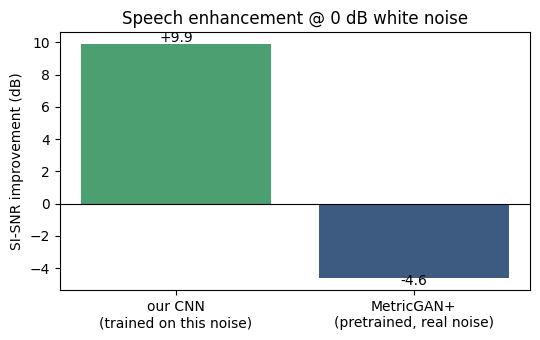

our CNN real-time factor: 0.011  (<1.0 = faster than real time on cpu)


In [12]:
plt.figure(figsize=(5.5, 3.5))
names = ["our CNN\n(trained on this noise)", "MetricGAN+\n(pretrained, real noise)"]
vals = [imp_ours, imp_mg]
bars = plt.bar(names, vals, color=["#4C9F70", "#3D5A80"])
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("SI-SNR improvement (dB)")
plt.title(f"Speech enhancement @ {EVAL_SNR_DB:.0f} dB white noise")
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v + (0.1 if v >= 0 else -0.4), f"{v:+.1f}", ha="center")
plt.tight_layout(); plt.show()

clip = eval_set[0][1]
t0 = time.time()
for _ in range(5):
    enhance_cnn(clip)
rtf = ((time.time() - t0) / 5) / (len(clip) / SR)
print(f"our CNN real-time factor: {rtf:.3f}  (<1.0 = faster than real time on {DEVICE})")

## Recap & next steps

**What we did:** pulled clean speech from Hugging Face, added synthetic noise, converted to
spectrograms with the STFT, trained a small PyTorch CNN to predict a speech mask, rebuilt the
waveform with the ISTFT, and compared against the pretrained MetricGAN+ model from the Hub.

**Ideas to improve it:**
- Train longer / on more data (use a larger speech dataset from the Hub).
- Add *real* noise (e.g. ESC-50 or DEMAND from Hugging Face) so the model handles realistic
  recordings, then re-compare with MetricGAN+ on its home turf.
- Predict the mask from log-mel features, or feed several frames of context.
- Replace the plain CNN with a U-Net or add a couple of recurrent layers for longer-range context.
- Train with an SI-SNR loss directly instead of the mask MSE.